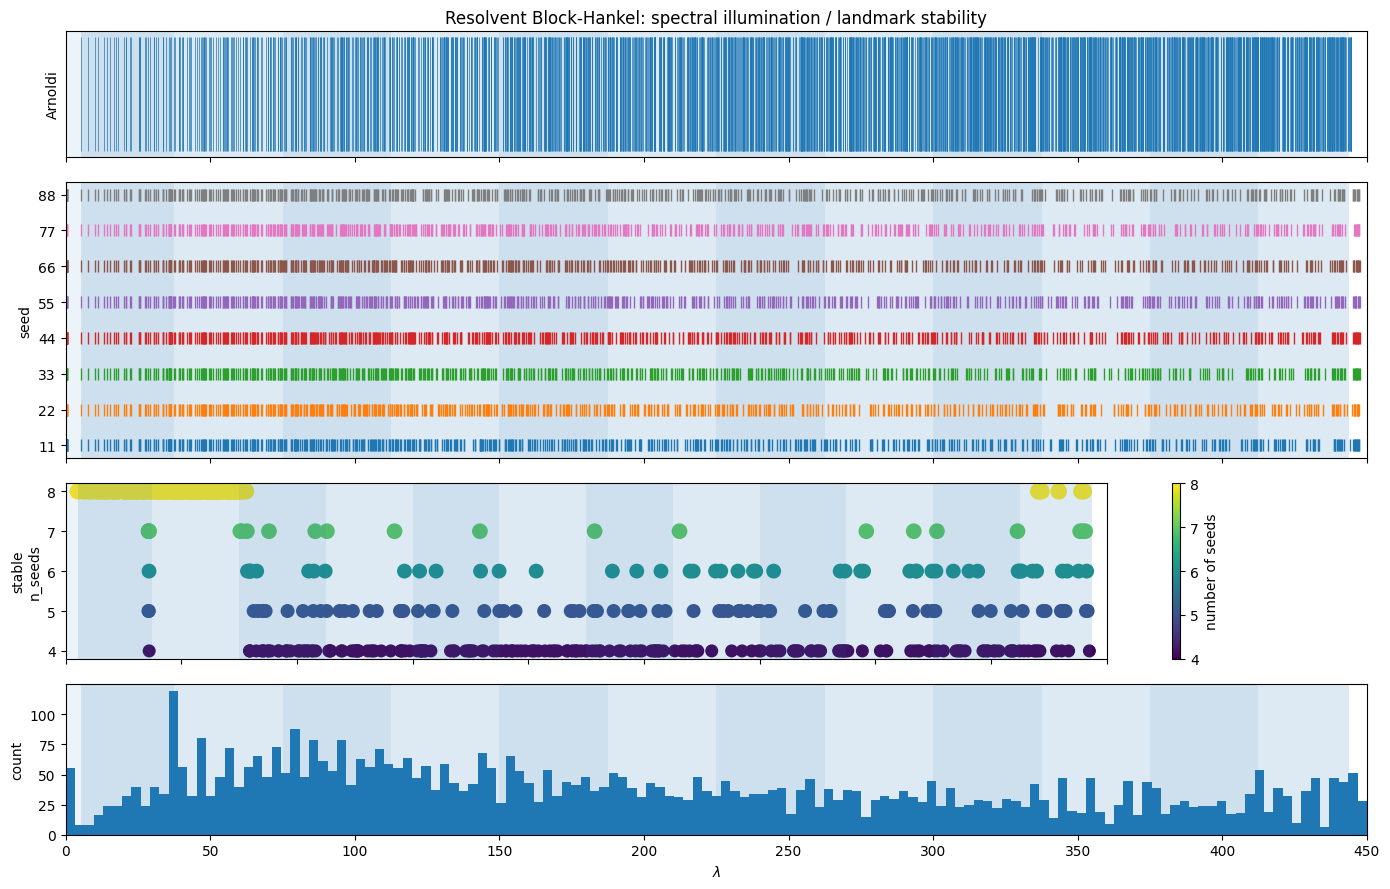

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE = Path("/home/esul01/data/outputs")
HANKEL_DIR = BASE / "hankel_resolvent_triaxial"
ANALYSIS = HANKEL_DIR / "analysis"

ARNOLDI_PATH = BASE / "arnoldi_reference_triaxial" / \
    "ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt"

SSG_PATH = BASE / "ssg_reference_triaxial" / \
    "ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt"

LANDMARKS_PATH = ANALYSIS / "hankel_seed_aware_landmarks.csv"
SUMMARY_PATH = ANALYSIS / "hankel_seed_aware_summary.json"

pattern = "ellipsoid_a1_b1.5_c2.3_P2_h0.06_resolvent_sigma100_top450_mom3000_win12_probe13_seed*_hankel_candidates.txt"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
arnoldi = np.loadtxt(ARNOLDI_PATH)
ssg = np.loadtxt(SSG_PATH)
landmarks = pd.read_csv(LANDMARKS_PATH)
summary = json.loads(SUMMARY_PATH.read_text())

candidate_files = sorted(HANKEL_DIR.glob(pattern))

all_candidates = []
seed_labels = []

for cf in candidate_files:
    vals = np.atleast_1d(np.loadtxt(cf))
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals >= 0) & (vals <= 450)]
    all_candidates.append(vals)

    meta_path = cf.with_name(cf.name.replace("_hankel_candidates.txt", "_hankel_meta.json"))
    meta = json.loads(meta_path.read_text())
    seed_labels.append(str(meta["seed"]))

lambda_lower = summary["lambda_reference_lower"]
lambda_upper = summary["lambda_reference_upper"]

# Reconstruct nominal windows from run config
n_windows = 12
lambda_top = 450.0
edges = np.linspace(0.0, lambda_top, n_windows + 1)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 2.2, 1.4, 1.2]}
)

# =========================
# 1) Arnoldi reference rug
# =========================
ax = axes[0]
for x in arnoldi:
    if 0 <= x <= 450:
        ax.vlines(x, 0, 1, linewidth=0.5)
ax.axvspan(lambda_lower, lambda_upper, alpha=0.15)
ax.set_ylabel("Arnoldi")
ax.set_yticks([])
ax.set_title("Resolvent Block-Hankel: spectral illumination / landmark stability")

# draw nominal windows
for i in range(n_windows):
    if i % 2 == 0:
        ax.axvspan(edges[i], edges[i+1], alpha=0.08)

# =========================
# 2) All seed candidates
# =========================
ax = axes[1]
for i, vals in enumerate(all_candidates):
    y = np.full_like(vals, i + 1, dtype=float)
    ax.plot(vals, y, "|", markersize=8, label=f"seed {seed_labels[i]}")
ax.axvspan(lambda_lower, lambda_upper, alpha=0.15)
for i in range(n_windows):
    if i % 2 == 0:
        ax.axvspan(edges[i], edges[i+1], alpha=0.08)
ax.set_ylabel("seed")
ax.set_yticks(range(1, len(seed_labels) + 1))
ax.set_yticklabels(seed_labels)

# =========================
# 3) Stable landmarks
# =========================
ax = axes[2]
sc = ax.scatter(
    landmarks["lambda_center"],
    landmarks["n_seeds"],
    c=landmarks["n_seeds"],
    s=22 + 12 * landmarks["n_seeds"],
)
ax.axvspan(lambda_lower, lambda_upper, alpha=0.15)
for i in range(n_windows):
    if i % 2 == 0:
        ax.axvspan(edges[i], edges[i+1], alpha=0.08)
ax.set_ylabel("stable\nn_seeds")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("number of seeds")

# =========================
# 4) Candidate density
# =========================
ax = axes[3]
all_vals_flat = np.concatenate(all_candidates) if all_candidates else np.array([])
bins = np.linspace(0, 450, 140)
ax.hist(all_vals_flat, bins=bins)
ax.axvspan(lambda_lower, lambda_upper, alpha=0.15)
for i in range(n_windows):
    if i % 2 == 0:
        ax.axvspan(edges[i], edges[i+1], alpha=0.08)
ax.set_ylabel("count")
ax.set_xlabel(r"$\lambda$")
ax.set_xlim(0, 450)

plt.tight_layout()
plt.show()

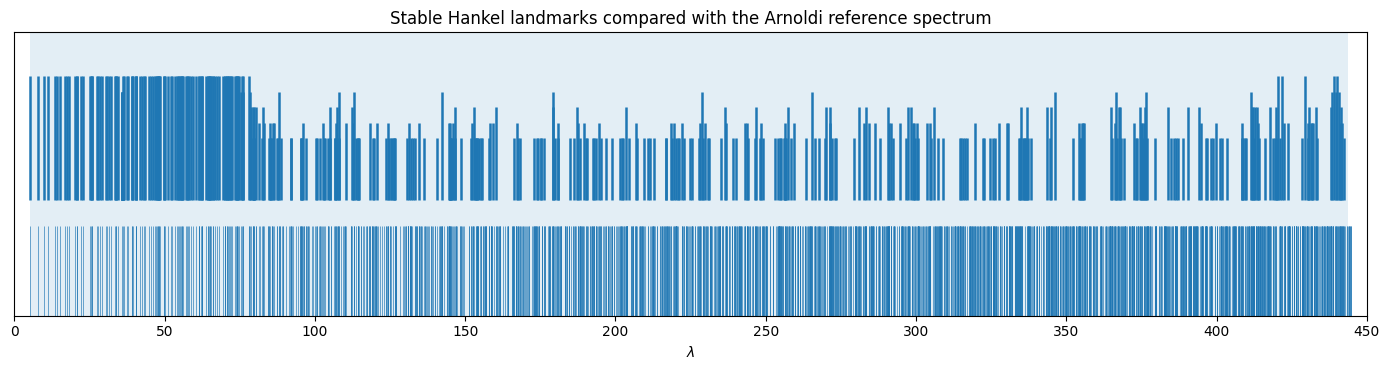

In [2]:
fig, ax = plt.subplots(figsize=(14, 3.8))

for x in arnoldi:
    if 0 <= x <= 450:
        ax.vlines(x, 0.0, 0.35, linewidth=0.45)

for _, row in landmarks.iterrows():
    x = row["lambda_center"]
    y0 = 0.45
    y1 = 0.45 + 0.06 * row["n_seeds"]
    ax.vlines(x, y0, y1, linewidth=1.8)

ax.axvspan(lambda_lower, lambda_upper, alpha=0.12)
ax.set_xlim(0, 450)
ax.set_ylim(0, 1.1)
ax.set_yticks([])
ax.set_xlabel(r"$\lambda$")
ax.set_title("Stable Hankel landmarks compared with the Arnoldi reference spectrum")
plt.tight_layout()
plt.show()

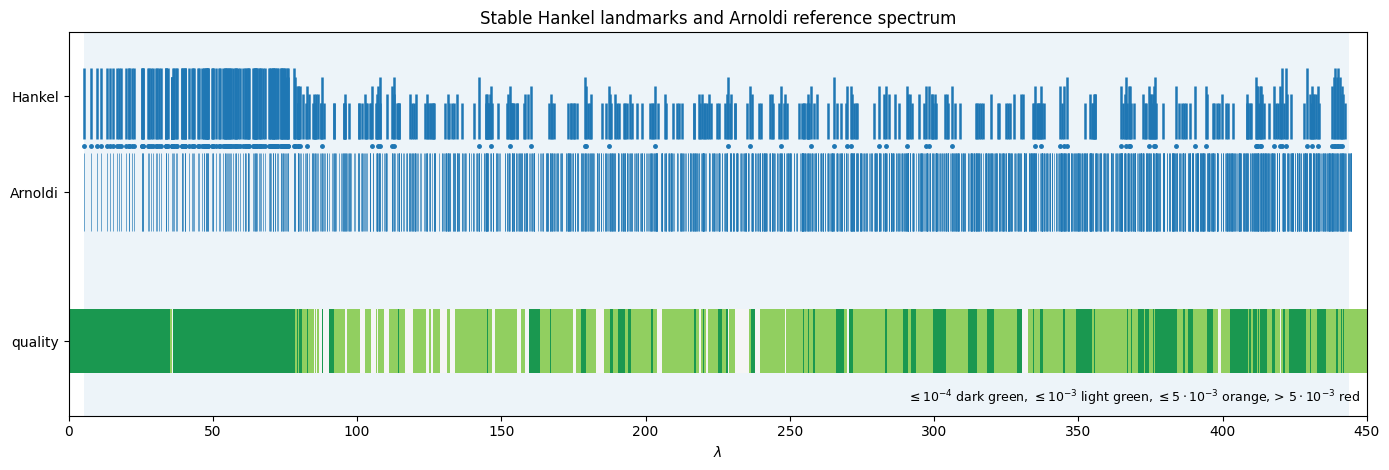

saved: /home/esul01/data/outputs/hankel_resolvent_triaxial/figures/hankel_landmarks_quality_strip.pdf
saved: /home/esul01/data/outputs/hankel_resolvent_triaxial/figures/hankel_landmarks_quality_strip.png


In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE = Path("/home/esul01/data/outputs")
HANKEL_DIR = BASE / "hankel_resolvent_triaxial"
ANALYSIS = HANKEL_DIR / "analysis"

ARNOLDI_PATH = BASE / "arnoldi_reference_triaxial" / \
    "ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt"

LANDMARKS_PATH = ANALYSIS / "hankel_seed_aware_landmarks.csv"
SUMMARY_PATH = ANALYSIS / "hankel_seed_aware_summary.json"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
arnoldi = np.loadtxt(ARNOLDI_PATH)
landmarks = pd.read_csv(LANDMARKS_PATH)
summary = json.loads(SUMMARY_PATH.read_text())

lambda_lower = summary["lambda_reference_lower"]
lambda_upper = summary["lambda_reference_upper"]

# Restrict to plotted interval
x_min = 0.0
x_max = 450.0

arnoldi_plot = arnoldi[(arnoldi >= x_min) & (arnoldi <= x_max)].copy()
lm = landmarks[(landmarks["lambda_center"] >= x_min) & (landmarks["lambda_center"] <= x_max)].copy()
lm = lm.sort_values("lambda_center").reset_index(drop=True)

# ------------------------------------------------------------
# Build interval-wise quality strip from nearest landmark midpoints
# ------------------------------------------------------------
x = lm["lambda_center"].to_numpy()
err = lm["arnoldi_abs_rel_err"].to_numpy()
nseeds = lm["n_seeds"].to_numpy()

# interval boundaries from midpoints
lefts = np.empty_like(x)
rights = np.empty_like(x)

if len(x) > 0:
    mids = 0.5 * (x[:-1] + x[1:])
    lefts[0] = x_min
    rights[-1] = x_max
    lefts[1:] = mids
    rights[:-1] = mids

def quality_color(e):
    if e <= 1e-4:
        return "#1a9850"   # dark green
    elif e <= 1e-3:
        return "#91cf60"   # light green
    else:
        return "#f5f5f5"   # neutral

colors = [quality_color(e) for e in err]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4.8))

# Common physical reference interval
ax.axvspan(lambda_lower, lambda_upper, alpha=0.08)

# 1) Arnoldi reference rug (bottom half)
for val in arnoldi_plot:
    ax.vlines(val, 0.52, 0.74, linewidth=0.45)

# 2) Hankel stable landmarks (top half), line height by number of seeds
for xi, ns, e in zip(x, nseeds, err):
    y0 = 0.78
    y1 = 0.78 + 0.025 * ns
    ax.vlines(xi, y0, y1, linewidth=1.8)

# 3) Quality strip
strip_y0 = 0.12
strip_h = 0.18

for L, R, c in zip(lefts, rights, colors):
    ax.add_patch(Rectangle((L, strip_y0), R - L, strip_h, facecolor=c, edgecolor="none"))

# 4) Optional: mark only highly stable landmarks with dots
high_stable = lm["n_seeds"] >= 6
ax.plot(
    lm.loc[high_stable, "lambda_center"],
    np.full(high_stable.sum(), 0.76),
    linestyle="None",
    marker="o",
    markersize=2.5,
)

# cosmetics
ax.set_xlim(x_min, x_max)
ax.set_ylim(0.0, 1.08)
ax.set_yticks([0.21, 0.63, 0.90])
ax.set_yticklabels(["quality", "Arnoldi", "Hankel"])
ax.set_xlabel(r"$\lambda$")
ax.set_title("Stable Hankel landmarks and Arnoldi reference spectrum")

# legend as text blocks
legend_text = (
    r"$\leq 10^{-4}$ dark green, "
    r"$\leq 10^{-3}$ light green, "
    r"$\leq 5\cdot 10^{-3}$ orange, "
    r"> $5\cdot 10^{-3}$ red"
)
ax.text(0.995, 0.02, legend_text, transform=ax.transAxes,ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

FIG_DIR = Path("/home/esul01/data/outputs/hankel_resolvent_triaxial/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

pdf_path = FIG_DIR / "hankel_landmarks_quality_strip.pdf"
png_path = FIG_DIR / "hankel_landmarks_quality_strip.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print("saved:", pdf_path)
print("saved:", png_path)